# Importación de librerías

In [2]:
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import filters_and_features as ff
import data_processor as dp

# Importación de datos

In [3]:
df = dp.lectura()

Se crean los dos tipos de dataframes

In [4]:
df_global = dp.create_df_global(df)
df_pure = dp.create_df_pure(df)

Se crea el dataframe df_block (otra celda porque es pesado)

In [5]:
df_block = dp.create_df_block(df)

In [6]:
df_block.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1848 entries, 0 to 1847
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sensor_1   1848 non-null   object
 1   Sensor_2   1848 non-null   object
 2   Sensor_3   1848 non-null   object
 3   Sensor_4   1848 non-null   object
 4   Sensor_5   1848 non-null   object
 5   Sensor_6   1848 non-null   object
 6   Sensor_7   1848 non-null   object
 7   Sensor_8   1848 non-null   object
 8   Sensor_9   1848 non-null   object
 9   Sensor_10  1848 non-null   object
 10  Sensor_11  1848 non-null   object
 11  Sensor_12  1848 non-null   object
 12  Sensor_13  1848 non-null   object
 13  Sensor_14  1848 non-null   object
 14  Stimulus   1848 non-null   int8  
dtypes: int8(1), object(14)
memory usage: 204.1+ KB


Visualización comparativa

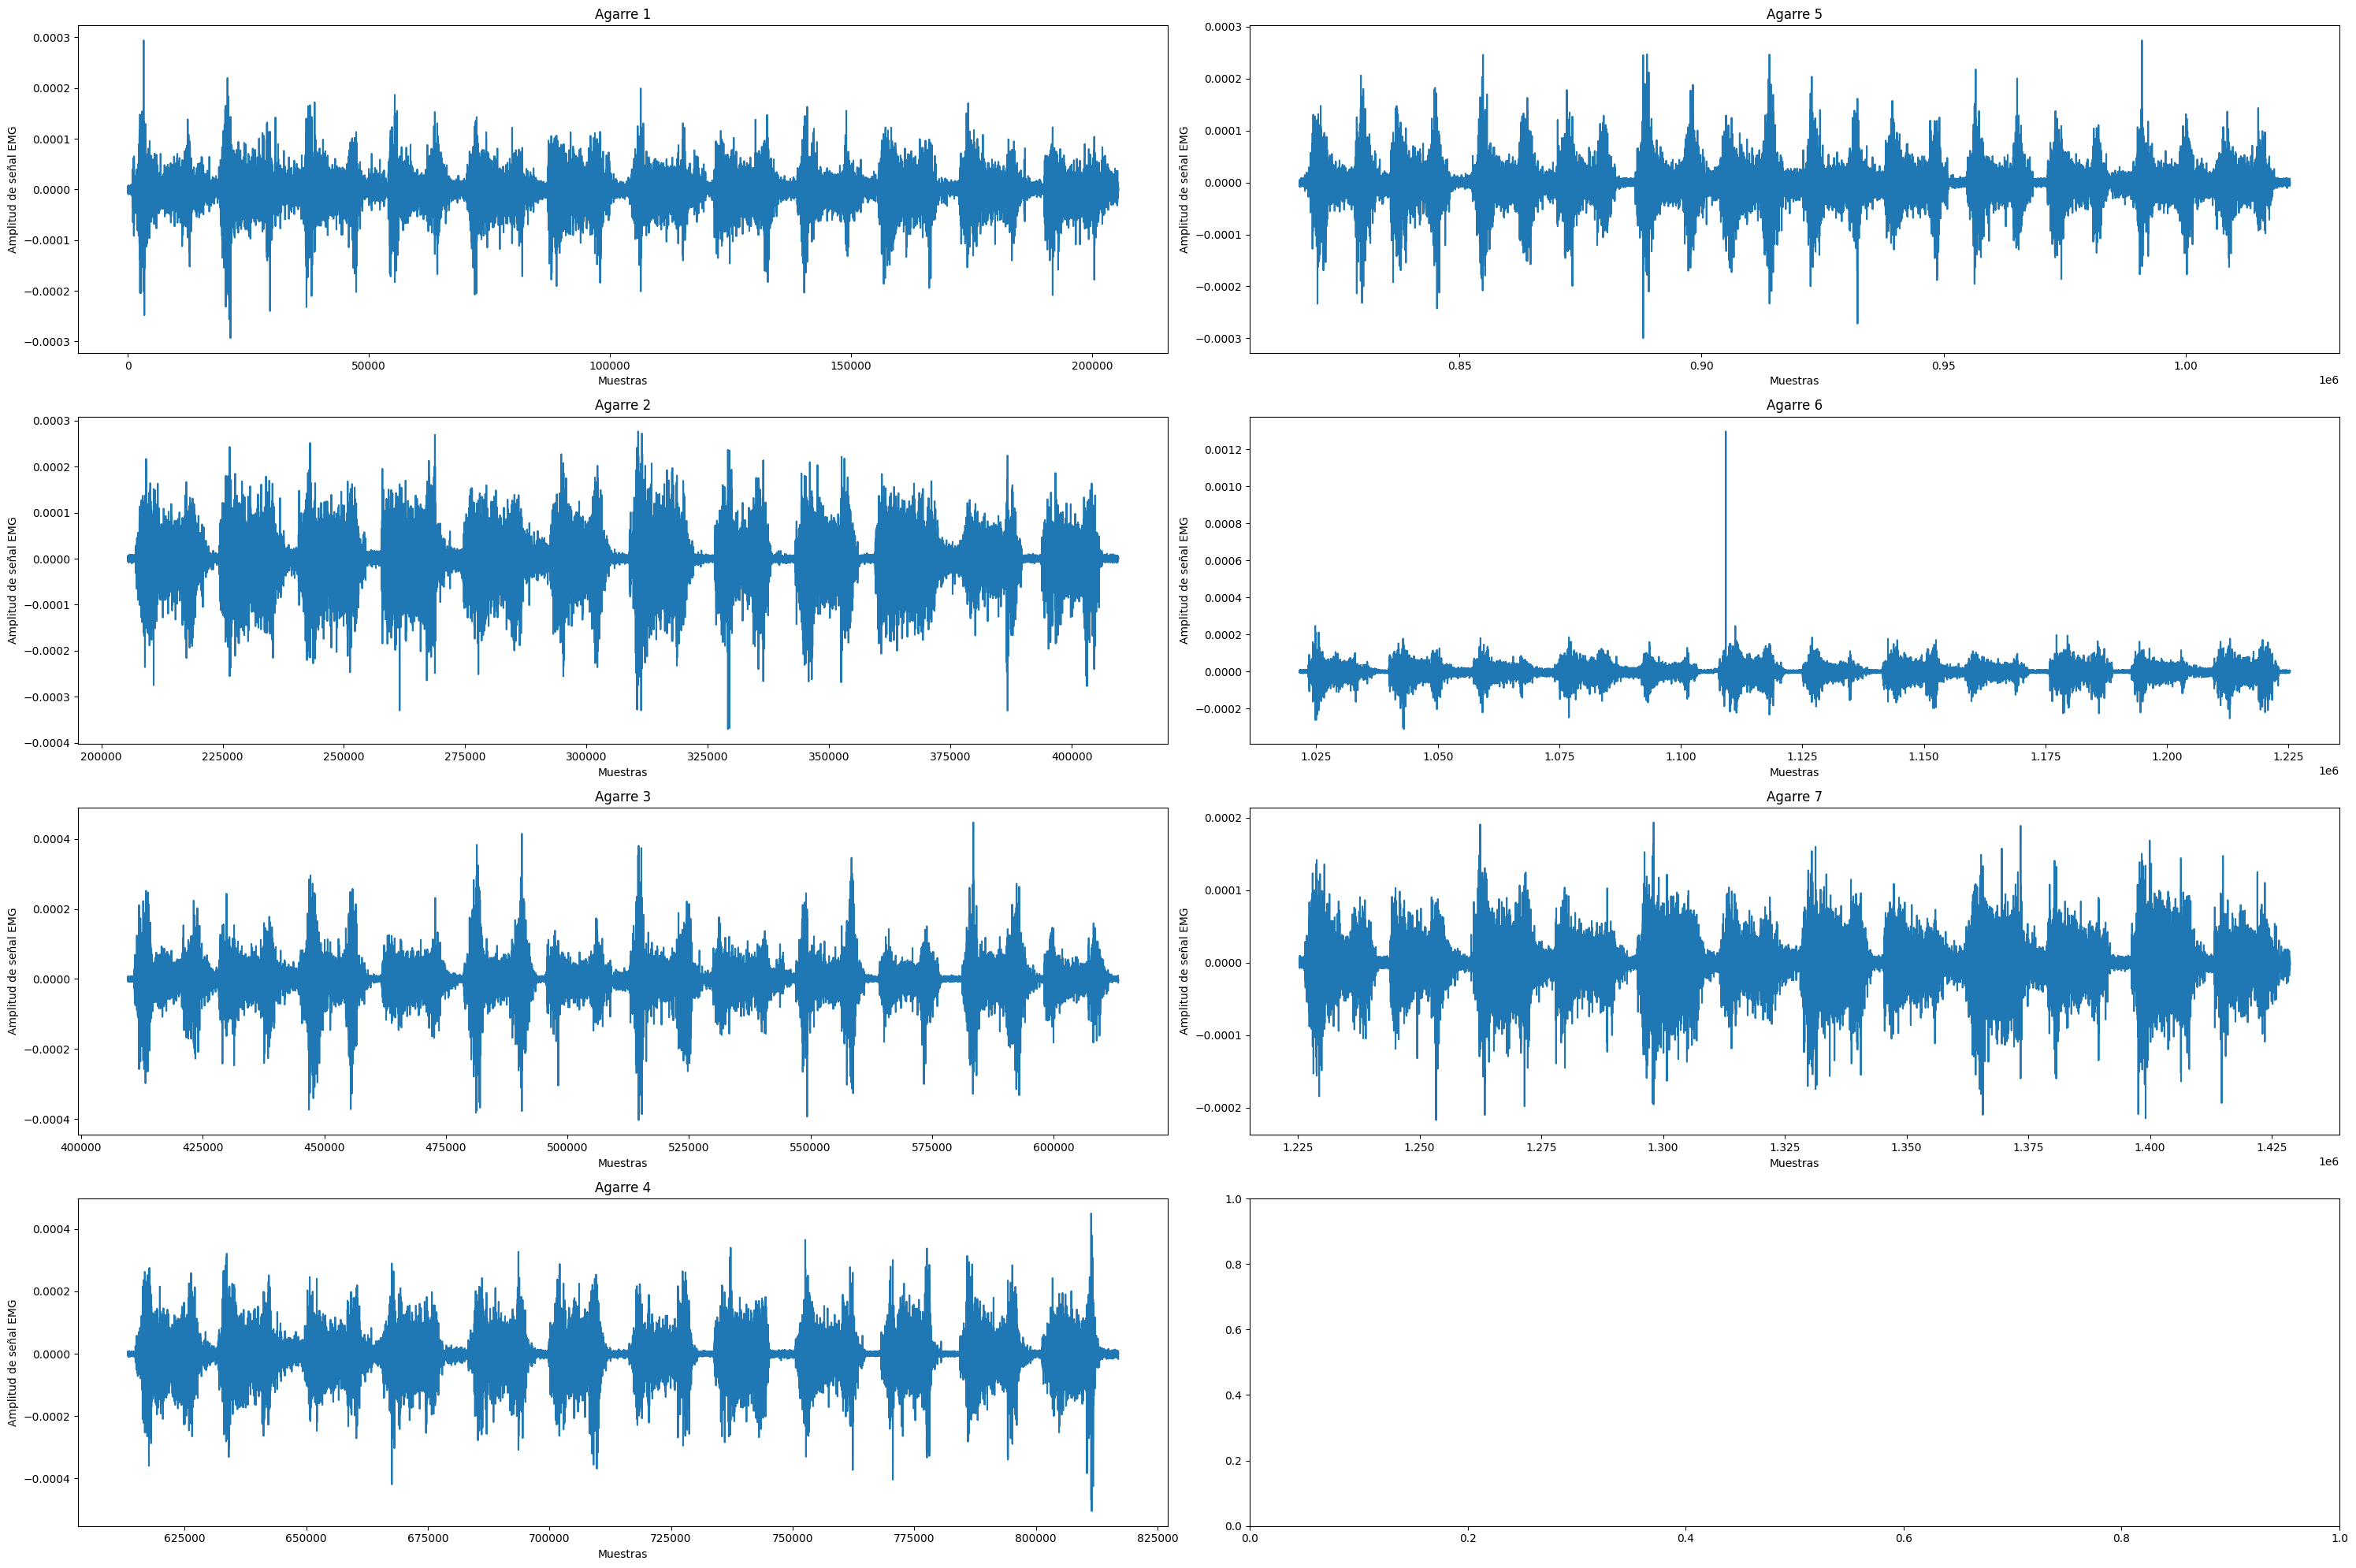

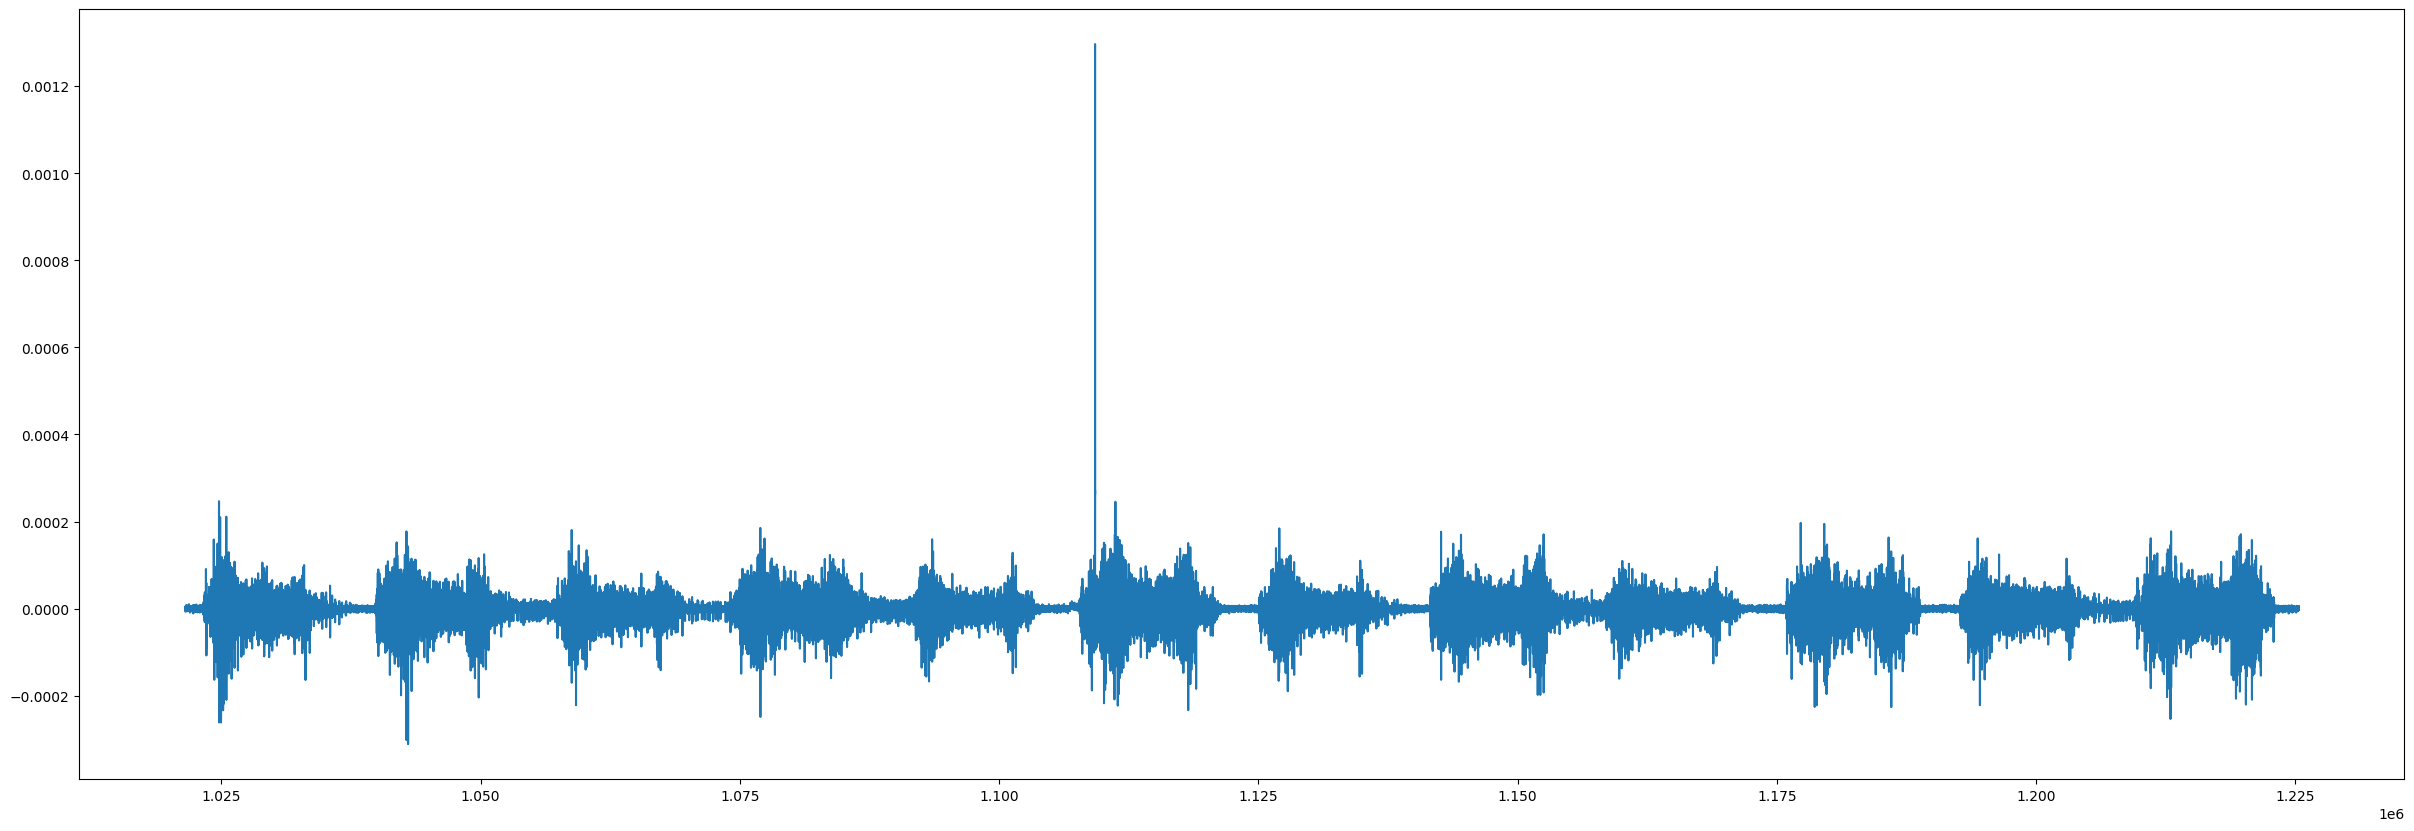

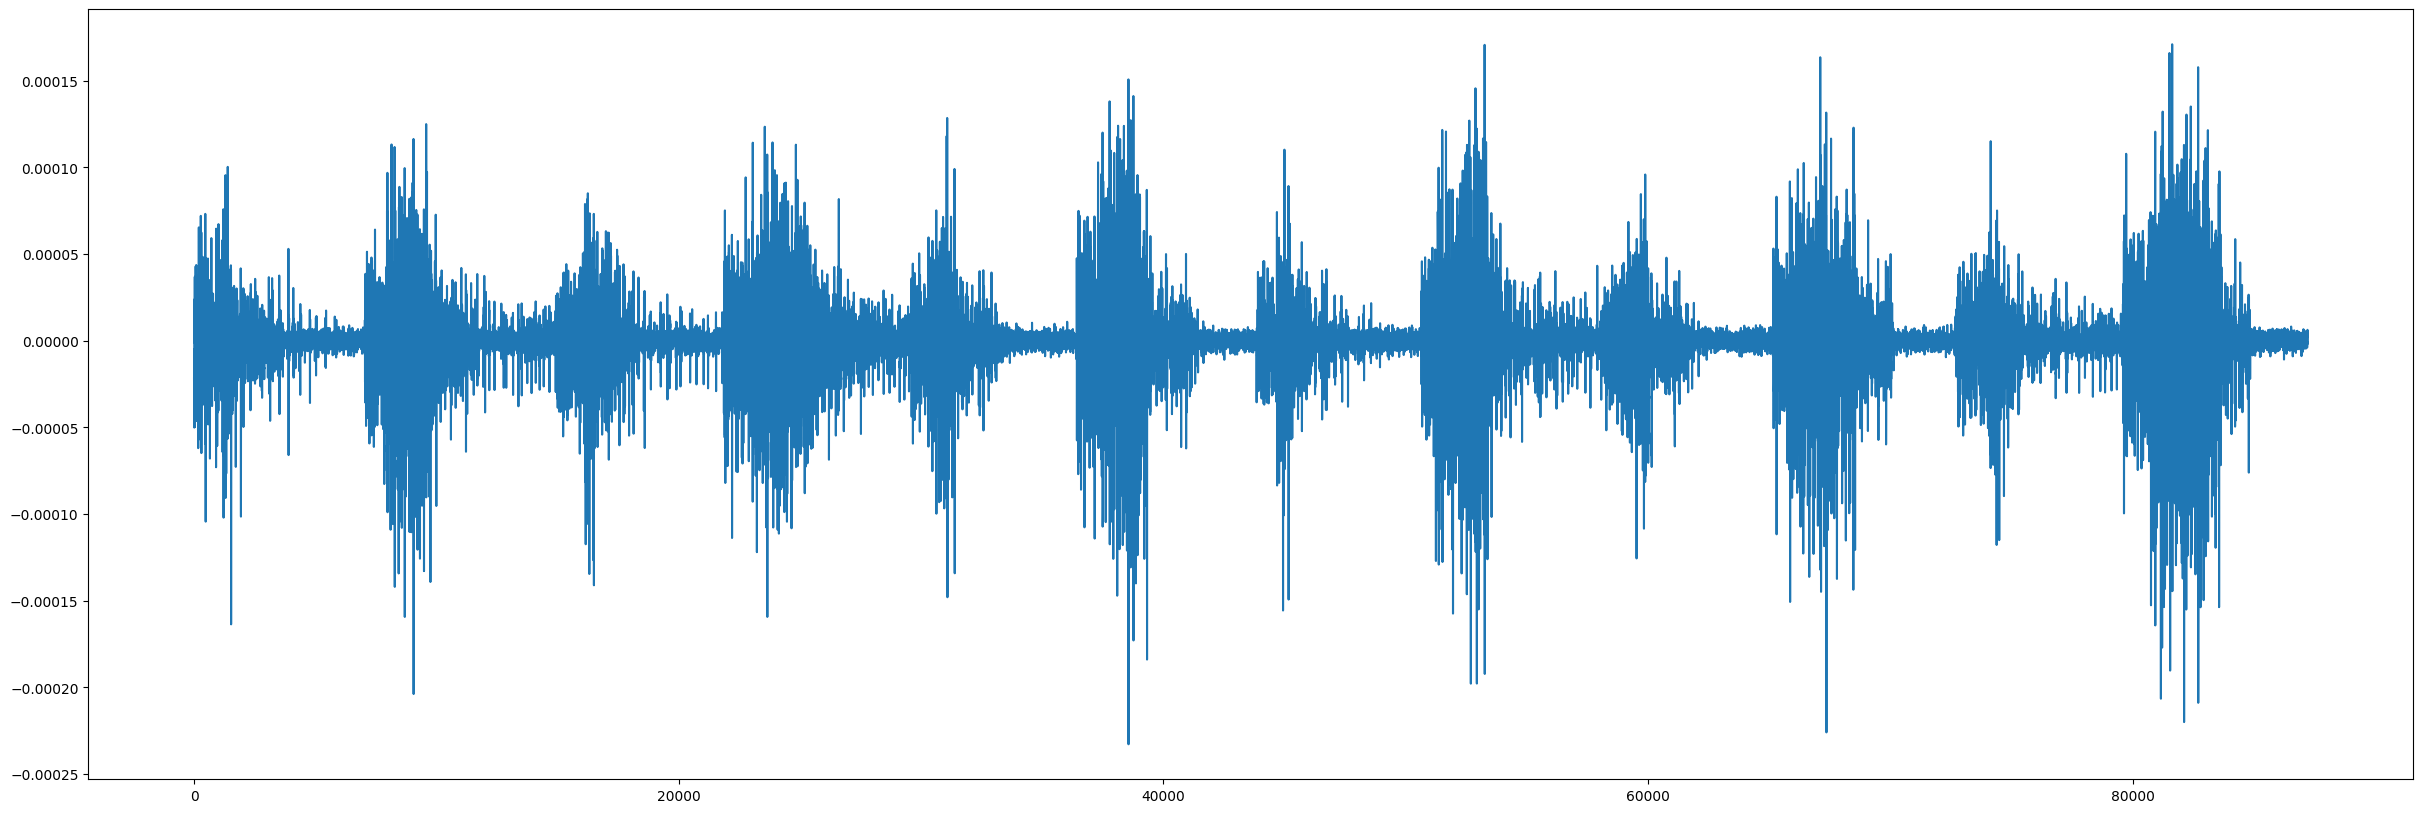

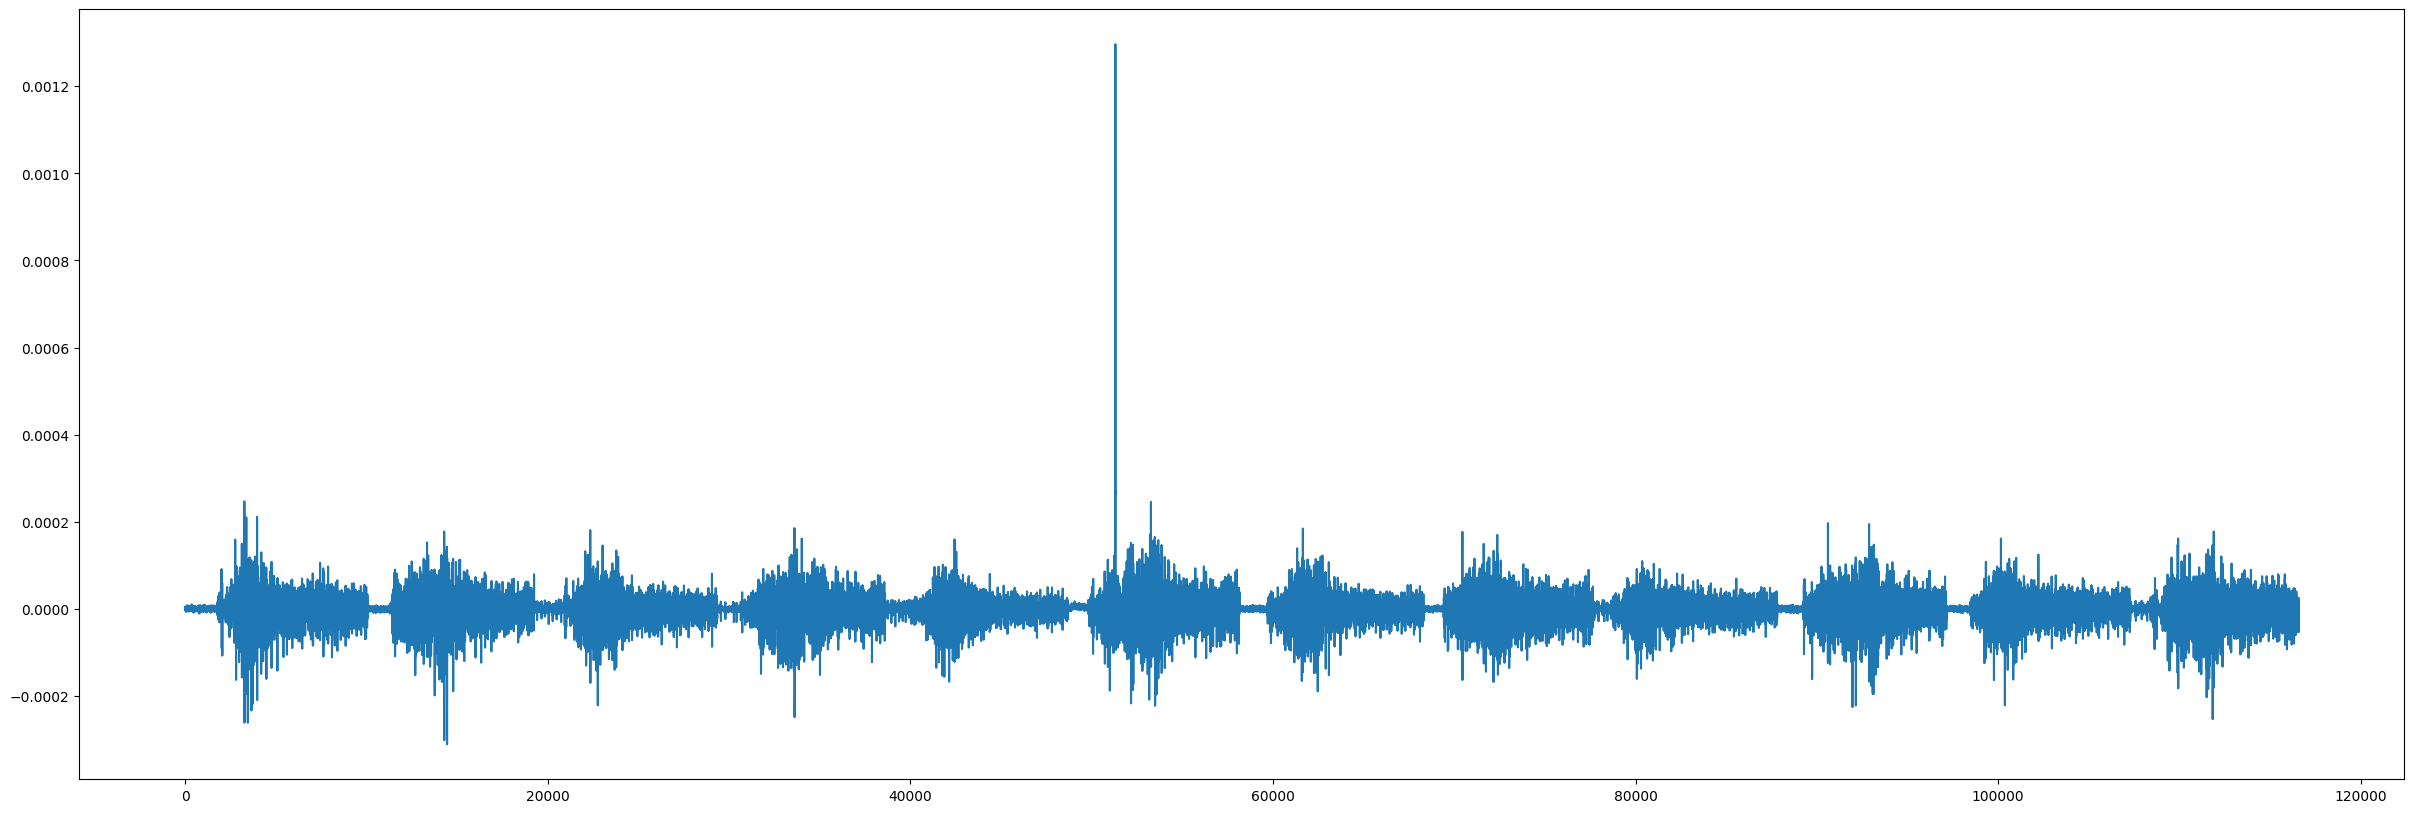

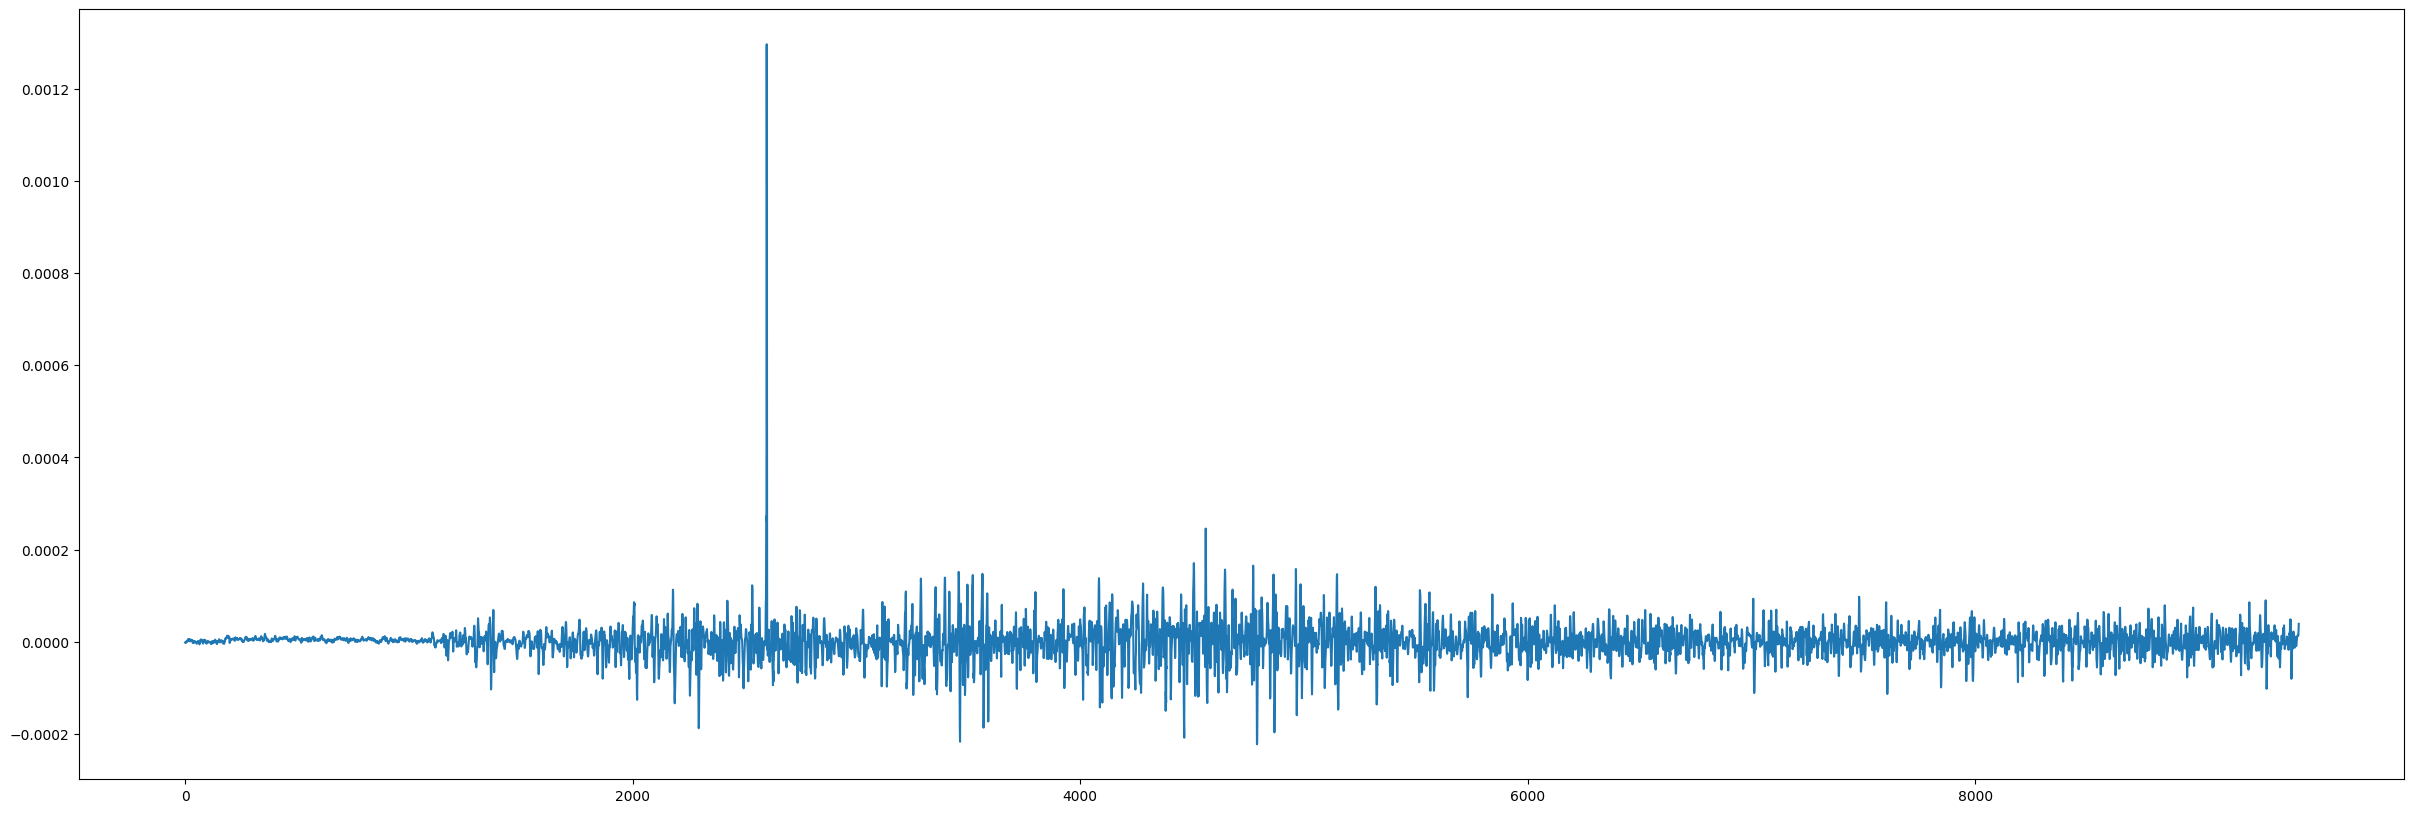

In [7]:
dp.raw_viewer(df)
dp.simple_viewer(df_global,5,0)
dp.simple_viewer(df_pure,10,0)
dp.simple_viewer(df_pure,11,0)
dp.simple_viewer(df_block,130,0)

# Filtro

Se filtran ambos tipos de dataframes

In [8]:
df_pure_filtered = dp.filtrar(df_pure)
df_global_filtered = dp.filtrar(df_global)

Procesando: 100%|██████████| 3/3 [00:16<00:00,  5.49s/it]


Se filtra solo el dataframe de bloques

In [9]:
df_block_filtered = dp.filtrar(df_block)

Procesando: 100%|██████████| 3/3 [01:08<00:00, 22.69s/it]


Visualización comparativa dataframe sin filtro y con filtro

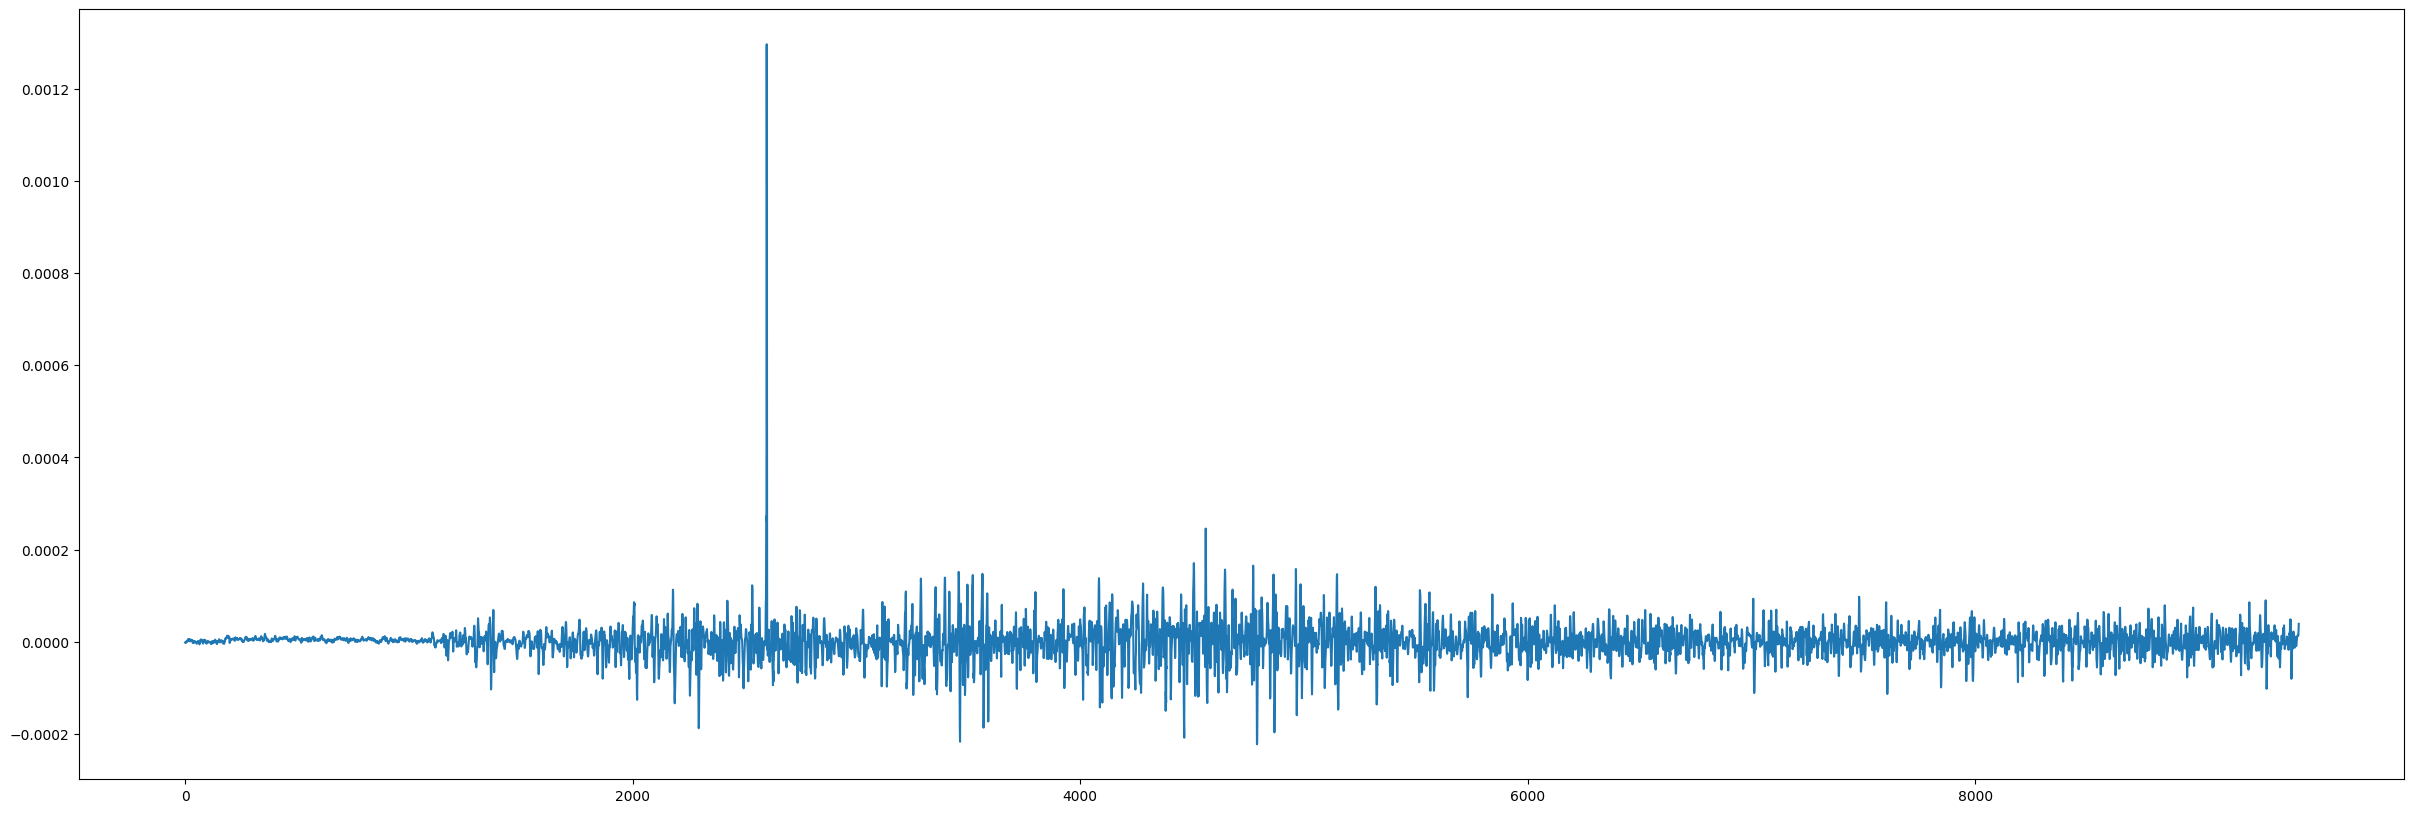

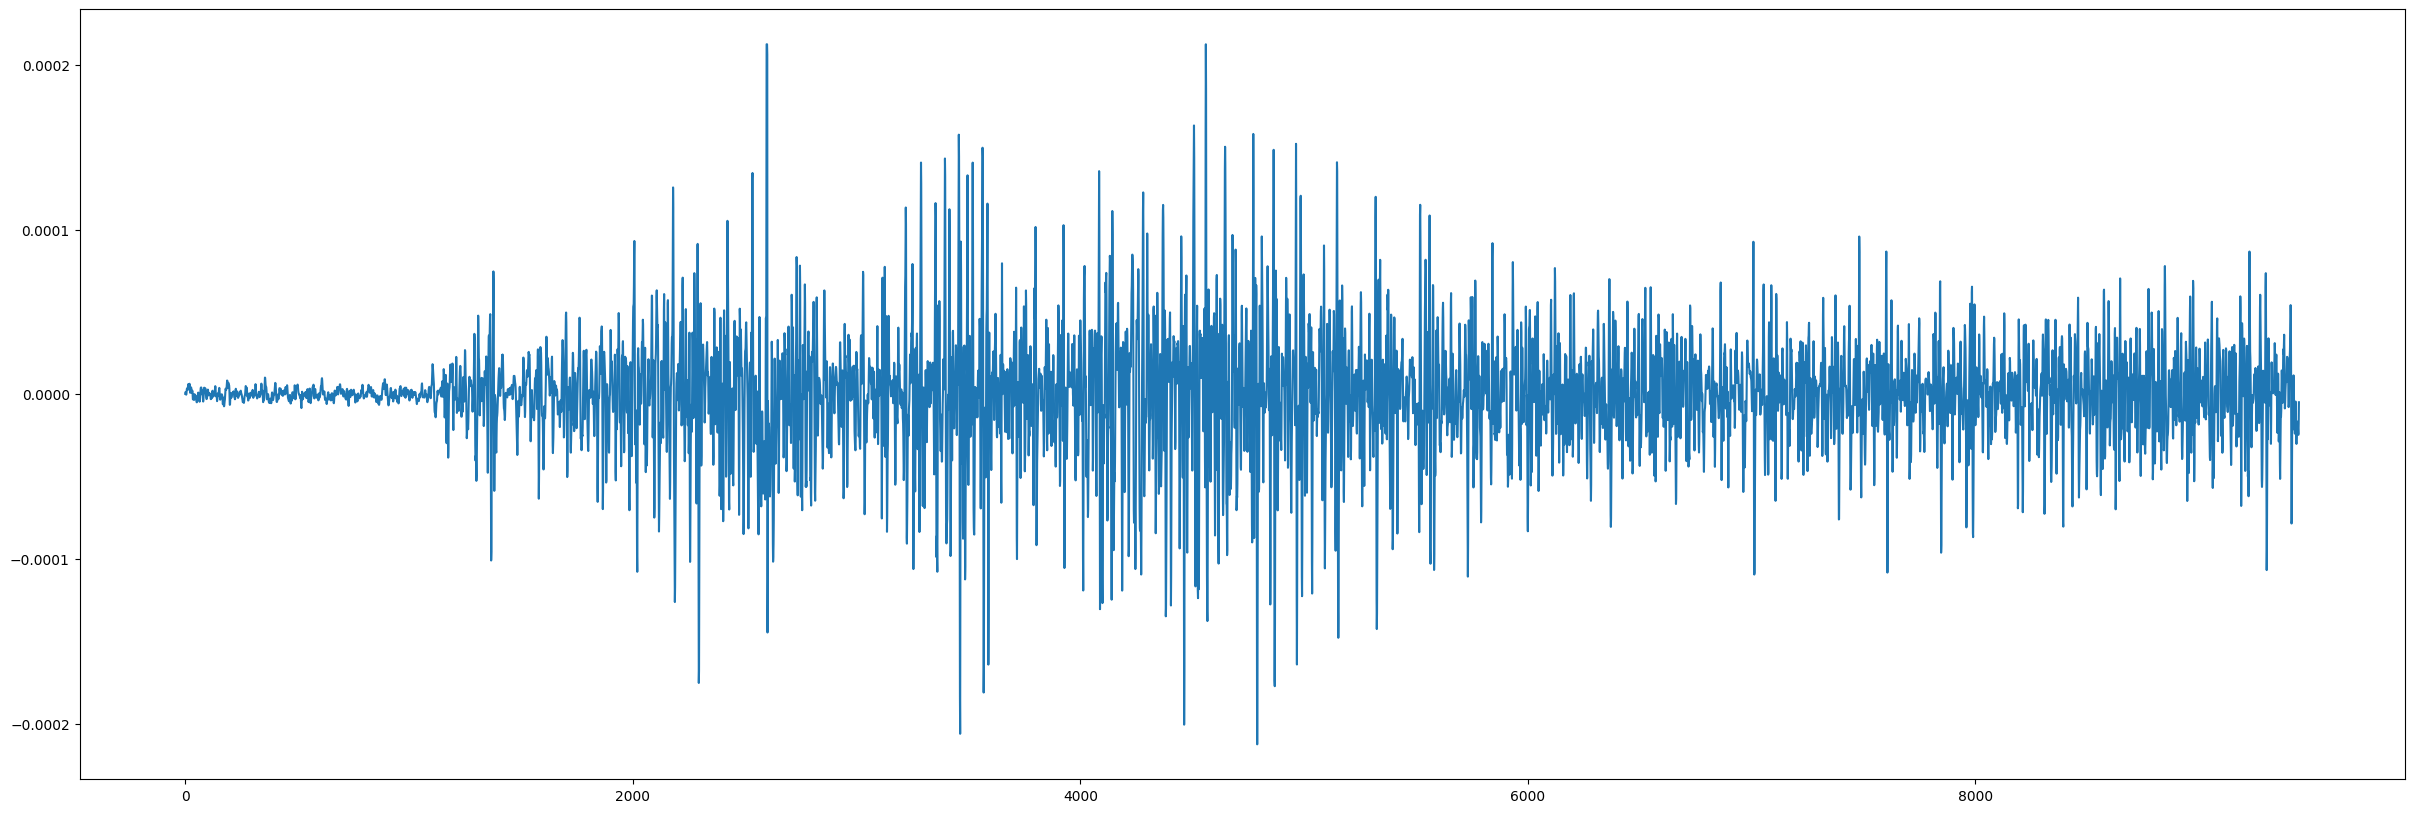

In [10]:
dp.simple_viewer(df_block,130,0)
dp.simple_viewer(df_block_filtered,130,0)

# Extracción de características

Dtaframes pure y global

In [11]:
df_pure_features = dp.gen_carac(df_pure_filtered)
df_global_features = dp.gen_carac(df_global_filtered)

Extrayendo Características: 100%|██████████| 77/77 [01:04<00:00,  1.20it/s]


Dataframe de bloques

In [12]:
df_block_features = dp.gen_carac(df_block_filtered)

Extrayendo Características: 100%|██████████| 1848/1848 [03:23<00:00,  9.07it/s]


In [13]:
df_block_features.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1848.000000,1.848000e+03,1848.000000,1848.000000,1848.000000,1.848000e+03,1848.000000,1.848000e+03,1848.000000,1848.000000,...,1848.000000,1848.000000,1.848000e+03,1.848000e+03,1848.000000,1.848000e+03,1848.000000,1848.000000,1848.000000,1848.000000
mean,0.000032,6.761249e-08,0.000018,0.089514,0.000007,5.539962e-09,0.001722,1.308828e-12,218.410941,80.378788,...,0.000005,0.017904,2.751407e-06,8.113235e-10,0.000331,2.027512e-13,181.422721,45.998377,1288.719697,3.142857
std,0.000016,2.666357e-07,0.000008,0.057105,0.000003,6.873460e-09,0.000964,1.501431e-12,24.379601,17.603539,...,0.000004,0.008718,1.373845e-06,2.014646e-08,0.000344,5.193025e-12,14.547994,9.504765,221.687248,4.016364
min,0.000007,-1.702326e-06,0.000004,0.014277,0.000002,2.123559e-10,0.000344,5.461991e-14,171.612843,39.000000,...,0.000002,0.005752,9.797974e-07,1.384843e-11,0.000092,3.691819e-15,97.554654,12.000000,515.000000,0.000000
25%,0.000021,-5.472155e-08,0.000012,0.049411,0.000005,1.838741e-09,0.001081,4.615501e-13,200.641748,67.000000,...,0.000003,0.011755,1.934688e-06,7.721760e-11,0.000213,2.025387e-14,174.240147,40.000000,1102.000000,0.000000
50%,0.000028,6.458440e-08,0.000016,0.074146,0.000007,3.214956e-09,0.001458,8.121753e-13,211.187295,77.000000,...,0.000004,0.015564,2.383850e-06,1.371453e-10,0.000280,3.365834e-14,182.446243,46.000000,1265.500000,0.500000
75%,0.000038,2.004886e-07,0.000022,0.113837,0.000009,6.216411e-09,0.002059,1.462665e-12,231.690973,92.000000,...,0.000006,0.021863,3.233567e-06,2.733499e-10,0.000386,6.629383e-14,189.778892,52.000000,1477.000000,6.000000
max,0.000105,2.056405e-06,0.000056,0.380752,0.000022,5.462246e-08,0.006225,1.182302e-11,286.948030,125.000000,...,0.000098,0.150995,1.735379e-05,8.629341e-07,0.012427,2.225473e-10,227.873480,79.000000,1855.000000,11.000000


# Normalización

In [14]:
df_pure_normalized = dp.normalizar(df_pure_features)
df_global_normalized = dp.normalizar(df_global_features)

In [15]:
df_block_normalized = dp.normalizar(df_block_features)

In [16]:
df_block_normalized.describe()

,rms_1,iemg_1,mav_1,wl_1,log_detec_1,ssi_1,fft_1,psd_1,mf_1,mdf_1,...,mav_14,wl_14,log_detec_14,ssi_14,fft_14,psd_14,mf_14,mdf_14,zc_14,stimulus
count,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,...,1.848000e+03,1.848000e+03,1.848000e+03,1.848000e+03,1848.000000,1848.000000,1.848000e+03,1.848000e+03,1.848000e+03,1848.000000
mean,9.227828e-17,7.689856e-18,1.153478e-16,-3.075943e-17,-2.768348e-16,-1.537971e-17,-1.230377e-16,1.076580e-16,-1.845566e-16,1.845566e-16,...,-2.153160e-16,9.227828e-17,-1.845566e-16,-1.345725e-17,0.000000,0.000000,-4.306320e-16,1.230377e-16,-1.307276e-16,3.142857
std,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,...,1.000271e+00,1.000271e+00,1.000271e+00,1.000271e+00,1.000271,1.000271,1.000271e+00,1.000271e+00,1.000271e+00,4.016364
min,-1.530472e+00,-6.639836e+00,-1.689279e+00,-1.317871e+00,-1.661849e+00,-7.753078e-01,-1.430663e+00,-8.355680e-01,-1.920079e+00,-2.351231e+00,...,-9.164022e-01,-1.394183e+00,-1.289876e+00,-3.959459e-02,-0.695188,-0.038342,-5.766484e+00,-3.577951e+00,-3.491085e+00,0.000000
25%,-6.792729e-01,-4.589300e-01,-7.231426e-01,-7.024627e-01,-7.699596e-01,-5.386257e-01,-6.656262e-01,-5.644664e-01,-7.290523e-01,-7.602113e-01,...,-4.439295e-01,-7.054318e-01,-5.946380e-01,-3.644831e-02,-0.343018,-0.035152,-4.938494e-01,-6.312624e-01,-8.424943e-01,0.000000
50%,-2.405705e-01,-1.135972e-02,-2.076700e-01,-2.692018e-01,-2.373749e-01,-3.383500e-01,-2.745190e-01,-3.308758e-01,-2.963790e-01,-1.919899e-01,...,-2.096567e-01,-2.684904e-01,-2.676114e-01,-3.347291e-02,-0.148010,-0.032570,7.037390e-02,1.708423e-04,-1.047691e-01,0.500000
75%,3.708886e-01,4.984781e-01,5.030660e-01,4.260449e-01,5.959061e-01,9.844131e-02,3.493016e-01,1.024878e-01,5.448665e-01,6.603421e-01,...,2.373066e-01,4.542836e-01,3.510516e-01,-2.671036e-02,0.160944,-0.026284,5.745419e-01,6.316041e-01,8.495359e-01,6.000000
max,4.636693e+00,7.460857e+00,4.801014e+00,5.101407e+00,4.488975e+00,7.142804e+00,4.674262e+00,7.004675e+00,2.812008e+00,2.535473e+00,...,2.652338e+01,1.526999e+01,1.063172e+01,4.280434e+01,35.180192,42.827593,3.193797e+00,3.473054e+00,2.555102e+00,11.000000


# Creación de dataframes de entrenamiento y testeo

Para el dataframe df_global

In [17]:
y_global = df_global_normalized.iloc[:, -1]
X_global = df_global_normalized.iloc[:, :-1]
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_global, y_global,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

Para el dataframe df_pure

In [18]:
y_pure = df_pure_normalized.iloc[:, -1]
X_pure = df_pure_normalized.iloc[:, :-1]
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_pure, y_pure,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

Para el dataframe df_block

In [19]:
y_block = df_block_normalized.iloc[:, -1]
X_block = df_block_normalized.iloc[:, :-1]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_block, y_block,
                                                    random_state=100,
                                                    test_size=0.30,
                                                    shuffle=True)

In [20]:
print(X_train_g.shape,y_train_g.shape)
print(X_train_p.shape,y_train_p.shape)
print(X_train_b.shape,y_train_b.shape)

(53, 154) (53,)
(107, 154) (107,)
(1293, 154) (1293,)


# Entrenamiento y testeo del modelo

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Entrenamiento

Modelo global

In [22]:
rf_g = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=1,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_g.fit(X_train_g, y_train_g)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 2418 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    2.0s finished


RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=4,
                       n_estimators=3000, n_jobs=-1, oob_score=True,
                       random_state=99, verbose=1)

Modelo puro

In [23]:
rf_p = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=1,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_p.fit(X_train_p, y_train_p)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 2418 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    2.1s finished


RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=4,
                       n_estimators=3000, n_jobs=-1, oob_score=True,
                       random_state=99, verbose=1)

Modelo bloque

In [24]:
rf_b = RandomForestClassifier(
    max_depth=20,             # Profundidad máxima de los árboles
    criterion='entropy',      # Criterio de medida para la calidad de la división ('entropy' o 'gini')
    min_samples_split=4,      # Número mínimo de muestras requeridas para dividir un nodo
    random_state=99,          # Para reproducibilidad del modelo
    n_estimators=3000,        # Número de árboles en el bosque
    verbose=1,                # Imprimir información durante el entrenamiento
    oob_score=True,           # Calcular la precisión del modelo fuera de la bolsa (OOB)
    n_jobs=-1                 # Usar todos los procesadores disponibles para acelerar el entrenamiento
)
rf_b.fit(X_train_b, y_train_b)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 418 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 768 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 1218 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 1768 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 2418 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 3000 out of 3000 | elapsed:    4.9s finished


RandomForestClassifier(criterion='entropy', max_depth=20, min_samples_split=4,
                       n_estimators=3000, n_jobs=-1, oob_score=True,
                       random_state=99, verbose=1)

Testeo

Global

In [25]:
y_pred_g = rf_g.predict(X_test_g)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 3000 out of 3000 | elapsed:    0.1s finished


Puro

In [26]:
y_pred_p = rf_p.predict(X_test_p)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 3000 out of 3000 | elapsed:    0.1s finished


Bloque

In [27]:
y_pred_b = rf_b.predict(X_test_b)

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 418 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 768 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 1218 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 1768 tasks      | elapsed:    0.3s
[Parallel(n_jobs=16)]: Done 2418 tasks      | elapsed:    0.4s
[Parallel(n_jobs=16)]: Done 3000 out of 3000 | elapsed:    0.5s finished


# Resultados

Matriz de confusión

Global

In [28]:
confusion_matrix(y_test_g, y_pred_g)

array([[4, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 2, 0, 0, 0],
       [0, 0, 2, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 2, 1, 0],
       [0, 0, 3, 0, 1, 2, 0],
       [0, 0, 0, 0, 2, 0, 3]])

Puro

In [29]:
confusion_matrix(y_test_p, y_pred_p)

array([[24,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  4,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  4,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  1],
       [ 0,  0,  0,  0,  0,  3,  0,  0],
       [ 0,  0,  0,  0,  0,  0,  3,  0],
       [ 0,  0,  0,  0,  0,  1,  0,  4]])

Bloque

In [30]:
confusion_matrix(y_test_b, y_pred_b)

array([[295,   0,   0,   0,   0,   0,   0,   0],
       [  0,  30,   0,   0,   0,   0,   0,   1],
       [  0,   0,  34,   5,  11,   0,   0,   0],
       [  0,   0,   2,  35,   2,   0,   0,   0],
       [  0,   0,   3,   1,  21,   0,   0,   0],
       [  0,   0,   0,   0,   0,  34,   1,   1],
       [  0,   0,   0,   2,   0,   1,  39,   0],
       [  0,   0,   0,   0,   0,   0,   0,  37]])

Precisión

Global

In [31]:
accuracy_score(y_pred_g, y_test_g)

0.5416666666666666

Puro

In [32]:
accuracy_score(y_pred_p, y_test_p)

0.8085106382978723

Bloque

In [33]:
accuracy_score(y_pred_b, y_test_b)

0.9459459459459459

In [34]:
print(classification_report(y_pred_g, y_test_g))
print(classification_report(y_pred_p, y_test_p))
print(classification_report(y_pred_b, y_test_b))

              precision    recall  f1-score   support

           1       0.80      1.00      0.89         4
           3       0.00      0.00      0.00         1
           4       1.00      0.40      0.57         5
           6       0.00      0.00      0.00         2
           9       0.67      0.40      0.50         5
          10       0.33      0.67      0.44         3
          11       0.60      0.75      0.67         4

    accuracy                           0.54        24
   macro avg       0.49      0.46      0.44        24
weighted avg       0.62      0.54      0.54        24

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       0.80      1.00      0.89         4
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         0
           6       0.00      0.00      0.00         4
           9       1.00      0.75      0.86         4
          10       1.00 

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz